# CPE 4309 Linear Regression - Closed solution single input
<div>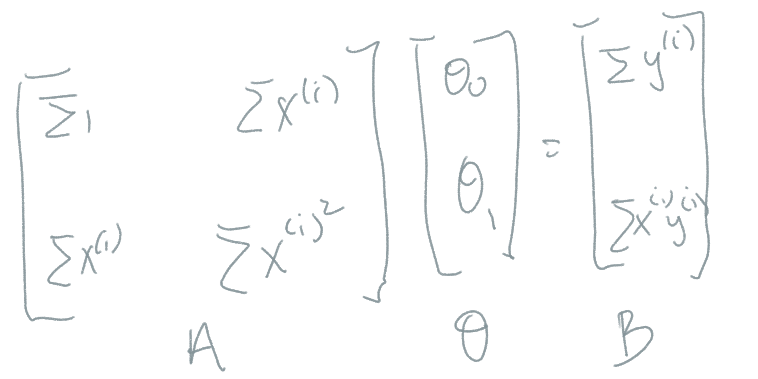<div>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
x = np.array([5.0, 10.0, 15.0])
y = np.array([3.0, 6.0, 7.0])
m = len(x)
#A = np.array([[np.sum(x ** 2), np.sum(x)], [np.sum(x), m]])
A = np.array([[m, np.sum(x)], [np.sum(x), np.sum(x ** 2)]])
B = np.array([[np.sum(y)], [np.sum(x*y)]])
print('A is: \n', A)
print('B is: \n', B)

A is: 
 [[  3.  30.]
 [ 30. 350.]]
B is: 
 [[ 16.]
 [180.]]


In [5]:
Ai = np.linalg.inv(A)
theta = np.dot(Ai, B)
theta0 = theta[0,0]
theta1 = theta[1,0]
print(f'theta0 is: {theta0:.3f}')
print(f'theta1 is: {theta1:.3f}')
print(f'Equation of linear regression is y = {theta0:.3f} + {theta1:.3f}x')

theta0 is: 1.333
theta1 is: 0.400
Equation of linear regression is y = 1.333 + 0.400x


# Let's plot the data and fitted line. #

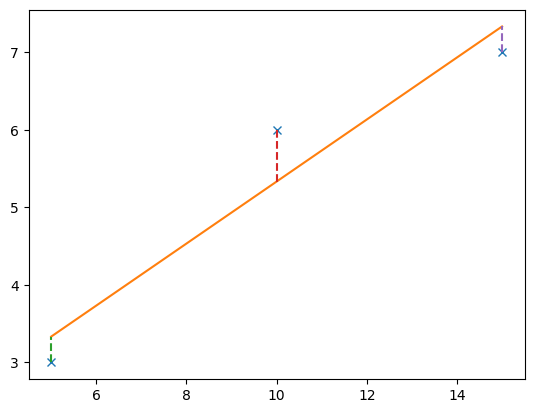

In [6]:
plt.plot(x, y, 'x')
plt.plot(x, theta1*x + theta0)
for i in range(m):
    plt.plot([x[i], x[i]], [y[i], theta1*x[i]+theta0], '--')

In [7]:
J = np.sum((y-(theta1*x+theta0))**2)/m
print(f'The cost J = sum squared error = {J:.3f}')           

The cost J = sum squared error = 0.222


## Vectorized Closed Form of LR ##
<div>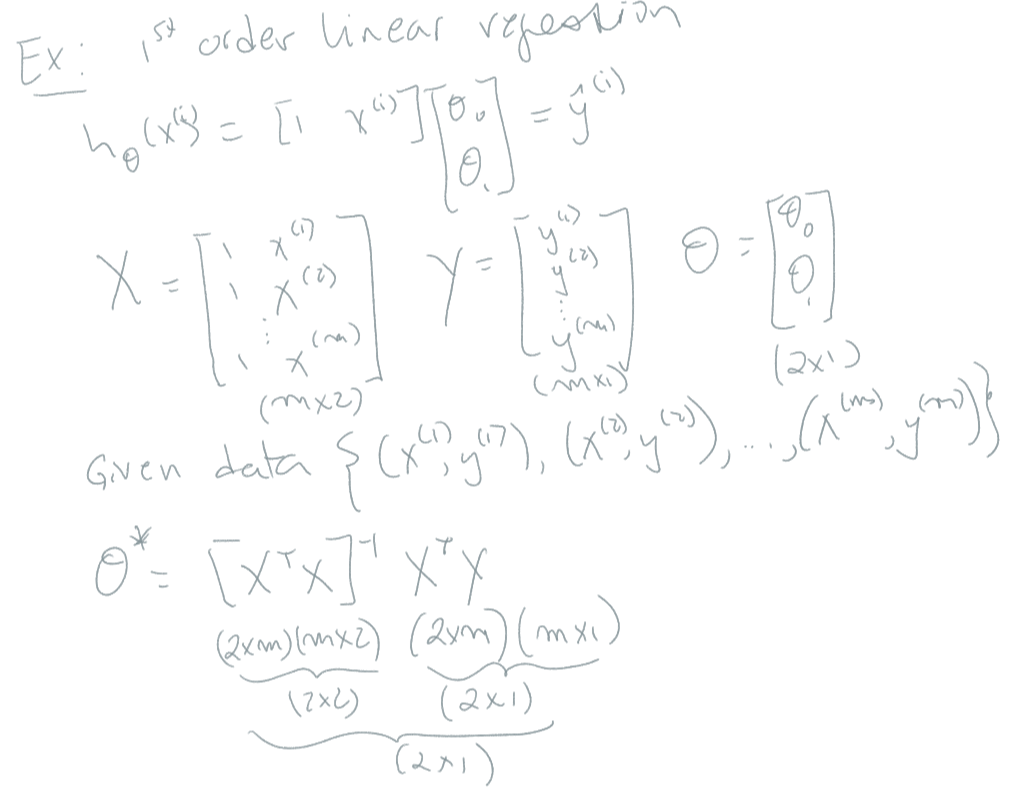<div>

In [8]:
X = np.zeros((m,2))
Y = np.zeros((m,1))
theta = np.zeros((2,1))
print(X)
print(Y)
print(theta)

[[0. 0.]
 [0. 0.]
 [0. 0.]]
[[0.]
 [0.]
 [0.]]
[[0.]
 [0.]]


In [9]:
for i in range(m):
    X[i,0] = 1
    X[i,1] = x[i]
    Y[i] = y[i]
    
print(X)
print(Y)

[[ 1.  5.]
 [ 1. 10.]
 [ 1. 15.]]
[[3.]
 [6.]
 [7.]]


In [10]:
temp1 = np.linalg.inv(np.dot(X.T,X))
temp2 = np.dot(X.T,Y)
theta = np.dot(temp1, temp2)
print(theta)

[[1.33333333]
 [0.4       ]]


In [11]:
temp1 = Y - np.dot(X,theta)
J = np.dot(temp1.T, temp1)/m
print(f'The cost J = sum squared error = {J[0,0]:.3f}') 

The cost J = sum squared error = 0.222


# Gradient method #
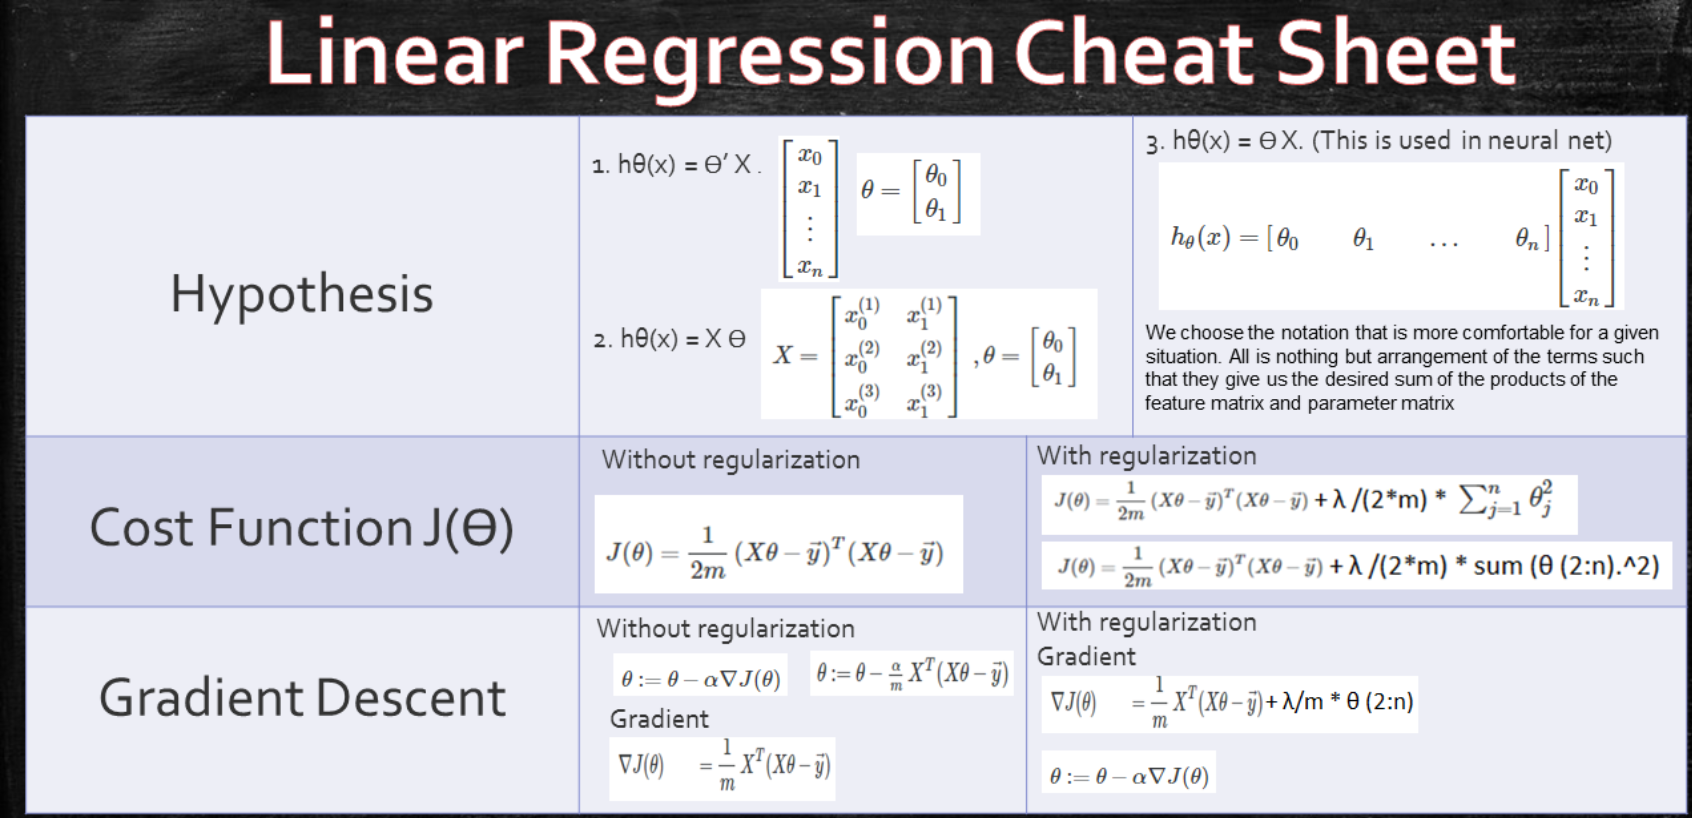

In [12]:
for i in range(m):
    X[i,0] = 1
    X[i,1] = x[i]
    Y[i] = y[i]
    
print(X)
print(Y)

[[ 1.  5.]
 [ 1. 10.]
 [ 1. 15.]]
[[3.]
 [6.]
 [7.]]


In [25]:
epoch = 200
#theta = np.random.randn(2,1)
theta = np.zeros((2,1))
alpha = .015

In [26]:
J = np.zeros((epoch,1))
for i in range(epoch):
    yhat = np.dot(X,theta)
    yerr = yhat - Y
    J[i,0] = (np.dot(yerr.T, yerr)).item()/m # scalar assignment
    deltaJ = np.dot(X.T, yerr)/m
    theta = theta - alpha*deltaJ
print(theta)

[[0.49104564]
 [0.47228395]]


Text(0.5, 1.0, 'Convergence of Cost Function (Zoomed In)')

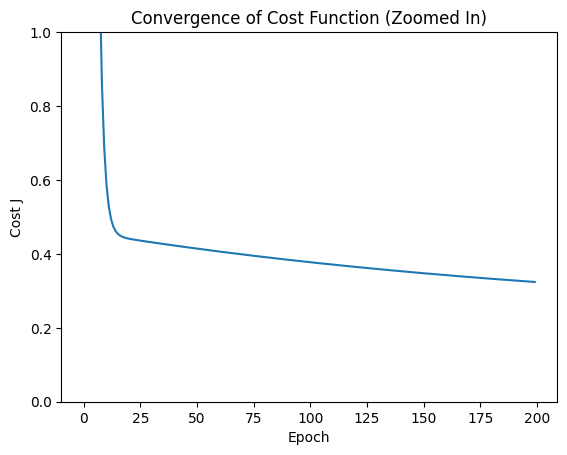

In [27]:
plt.ylim(0, 1) 
plt.plot(J)
# Add labels for clarity
plt.xlabel("Epoch")
plt.ylabel("Cost J")
plt.title("Convergence of Cost Function (Zoomed In)")

In [31]:
theta0_grad = theta[0]
theta1_grad = theta[1]

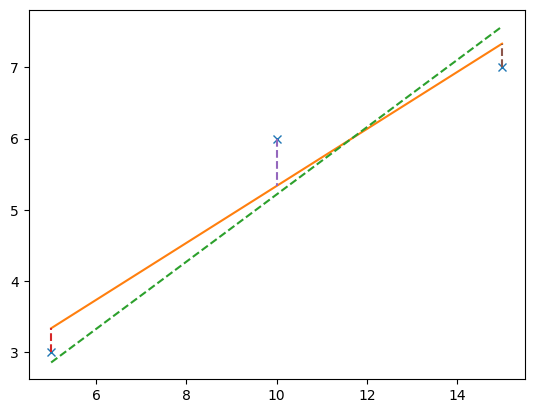

In [33]:
plt.plot(x, y, 'x')
plt.plot(x, theta1*x + theta0)
plt.plot(x, theta1_grad*x + theta0_grad, '--')
for i in range(m):
    plt.plot([x[i], x[i]], [y[i], theta1*x[i]+theta0], '--')